# Experiments with new optimiser
------

## Imports

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
from functions import *
from scipy.optimize import minimize, Bounds
from tqdm import tqdm

## Constants

In [2]:
N = 2 ** 20
N_16 = 2 ** 16
p = 1-e**-2 # our table coverage

## Numerical Optimisation

In [3]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor):   # add v_cost if want vanilla cost to be set beforehand
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    # lower bounds and upper bounds for the input variables
    bound = Bounds([1 for i in range(t)], [float("inf") for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    res = minimize(lambda Kj: m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1})
    
    ## res.x is the result of the optimization
    final_cost, m_values = cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Test lower cost bounds with new optimiser

In [4]:
# first do 1.125 1.25 and 1.5 for N = 2^16 like we did for N = 2^20

def test_cost_factors_around_1(N, p, alphas, factors):
    
    # for each factor
    for factor in tqdm(factors, desc="Processing factors"):
        # place to store all the kj's for the factor
        results = []
        
        # for each alpha
        for alpha in tqdm(alphas, desc="Processing alphas"):
            K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor)
            # plot_kjs_cost(N, K_js, m_0, alpha, factor)
            results.append([K_js, m_0, final_cost, m_values])
            
        # store all kj's for the factor in a .pickle file
        with open(f"N_16/around_1/{factor}P(V)/factor_{factor}_new_op.pickle", "wb") as f:
            pickle.dump(results, f)
        
        # plot all alpha kjs on the same graph
        plot_all_alpha(results, N_16, factor)
        

Processing alphas:  12%|█▎        | 1/8 [00:00<00:03,  1.83it/s]

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1585.2476851395297
            Iterations: 12
            Function evaluations: 972
            Gradient evaluations: 12



Processing alphas:  25%|██▌       | 2/8 [00:01<00:03,  1.94it/s]

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1680.041508690245
            Iterations: 12
            Function evaluations: 972
            Gradient evaluations: 12



Processing alphas:  38%|███▊      | 3/8 [00:01<00:02,  1.93it/s]

...


Processing alphas:  88%|████████▊ | 7/8 [00:02<00:00,  2.56it/s]

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1895.8569734041234
            Iterations: 9
            Function evaluations: 730
            Gradient evaluations: 9



Processing alphas: 100%|██████████| 8/8 [00:03<00:00,  2.37it/s]

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1991.5045742283603
            Iterations: 9
            Function evaluations: 730
            Gradient evaluations: 9



Processing factors: 100%|██████████| 3/3 [00:12<00:00,  4.12s/it]


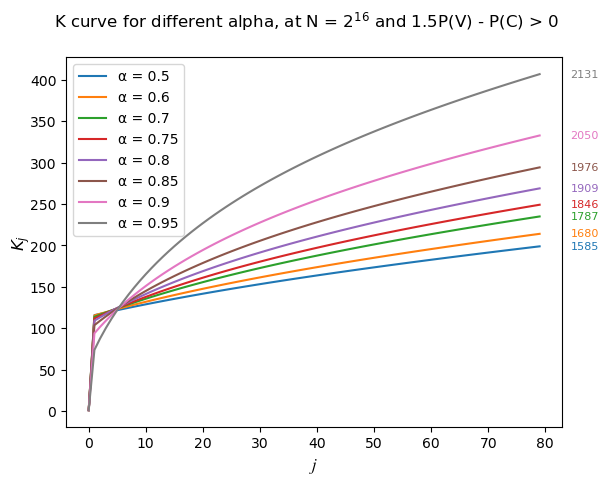

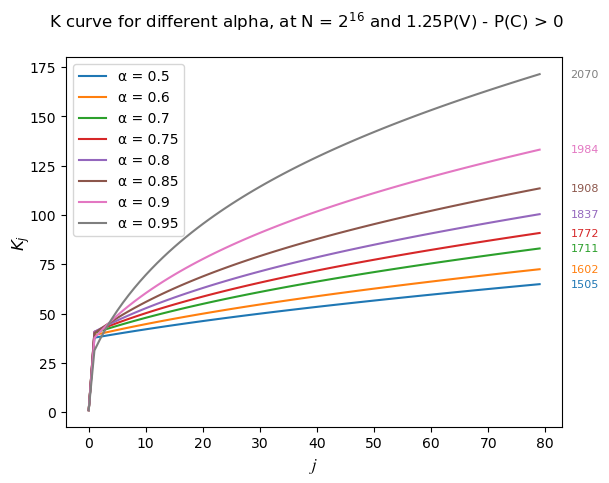

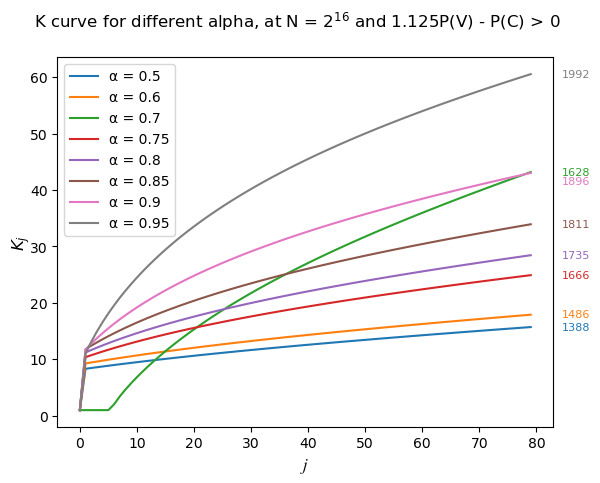

In [5]:
# run all the factors around 1

factors = [1.5, 1.25, 1.125]
alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
test_cost_factors_around_1(N_16, p, alphas, factors)


In [6]:
with open(f"N_16/around_1/1.125P(V)/factor_1.125_new_op.pickle", "rb") as f:
    results = pickle.load(f)

# [K_js, m_0, final_cost, m_values]
results[0][3][-1]

1387.5079062534699